# [LAB-07] 6. 일원분산분석 (One-way ANOVA)

## #01. 준비작업

### 1. 패키지 설치

`pingouin` 패키지와 `statsmodels` 패키지의 설치가 필요하다

In [1]:
!pip install --upgrade pingouin

In [2]:
!pip install --upgrade statsmodels

### 2. 라이브러리 참조

In [3]:
from jussam import load_data
from helpers import *
from pandas import pivot_table

# 분산분석을 위한 라이브러리
from scipy.stats import f_oneway
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm
from pingouin import anova
from pingouin import welch_anova

📦 연세대학교 주영아 교수가 제작한 라이브러리를 사용중입니다.
📧 Email(1): j.purplerose@yonsei.ac.kr
📧 Email(2): j.purplerose@gmail.com
📝 Website: https://juyounga.kr/


### 3. 데이터 가져오기

`tree_weight` 데이터셋은 소나무 품종별 무게를 조사한 데이터이다. 소나무 품종별로 평균 무게에 차이가 있는지 분석하라.

In [4]:
origin = load_data('tree_weight')
origin

📚 소나무 품종별 무게를 조사한 데이터 (출처: 방송통신대학교 통계학개론)


,weight,group
0,4.170,A
1,5.580,A
2,5.180,A
3,6.110,A
4,4.500,A
5,4.610,A
6,5.170,A
7,4.530,A
8,5.330,A
9,5.140,A


## #02. 데이터 분포 및 가정 확인

### 1. 데이터 분포

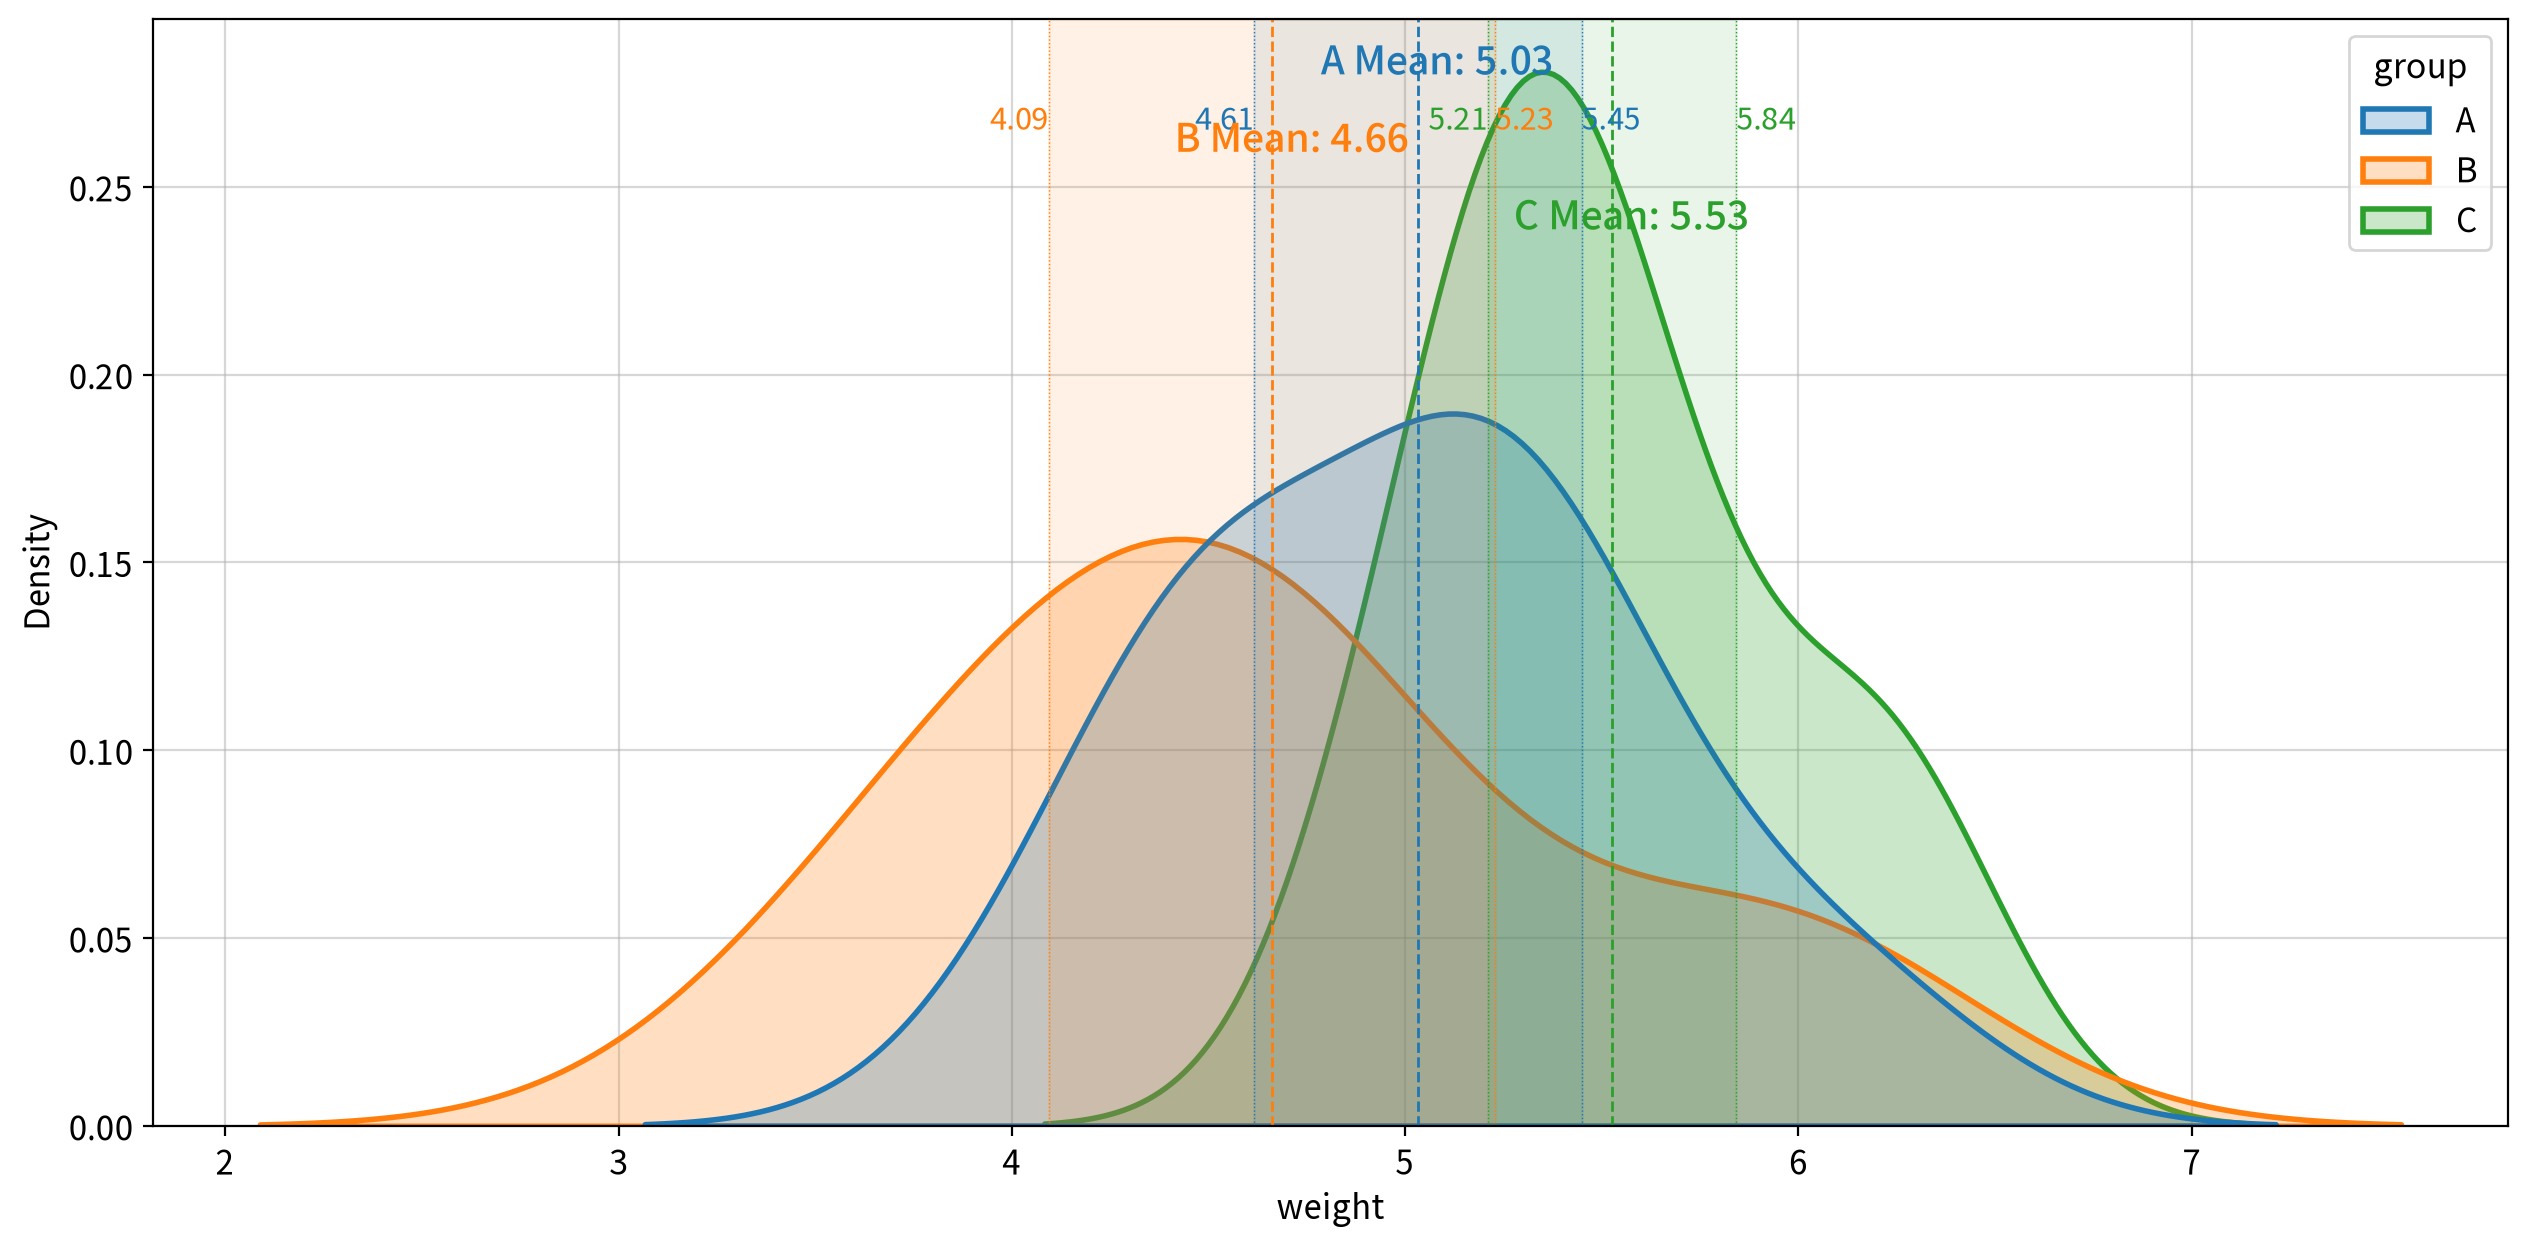

In [5]:
my_plot.kdeplot(origin, x='weight', hue='group', fill=True, meanline=True, clevel=0.95)

#### 💡인사이트

- **분산분석의 동기**: 평균이 B(4.66) < A(5.03) < C(5.53)로 벌어져 있어 집단 간 변동을 검정할 가치가 있음
- **정규성 가정**: 세 분포가 종 모양 대칭 → normaltest로 확인
- **등분산성 가정**: 분포 폭이 비슷 → Bartlett로 확인, 위반 시 Welch-ANOVA
- **겹침**: 분포가 많이 겹쳐 눈으로 단정 불가, F·p로 판단 필요
- **사후검정 예고**: B와 C는 신뢰수준 영역이 거의 안 겹치나 A는 애매 → 어느 쌍이 다른지는 사후검정 필요

### 2. long 타입 데이터로 변환

- 가설검정의 가정 확인을 위해 long 타입의 데이터를 wide 타입으로 변환해야 한다.

In [6]:
df_wide = my_prep.long2wide(origin, hue='group', values='weight')
df_wide

,A,B,C
0,4.170,4.810,6.310
1,5.580,4.170,5.120
2,5.180,4.410,5.540
3,6.110,3.590,5.500
4,4.500,5.870,5.370
5,4.610,3.830,5.290
6,5.170,6.030,4.920
7,4.530,4.890,6.150
8,5.330,4.320,5.800
9,5.140,4.690,5.260


### 3. 가설검정의 가정 확인

In [7]:
my_stats.test_assumptions(df_wide)

,test,statistic,p-value,result
field,,,,
A,normaltest,0.233,0.890,True
B,normaltest,0.968,0.616,True
C,normaltest,1.013,0.603,True
Bartlett,equal_var,2.879,0.237,True


> 정규성과 등분산성을 모두 충족한다.

## #03. 일원분산분석

### 1. scipy 패키지를 사용하는 경우

- wide 타입의 데이터프레임을 사용해야 한다.
- 등분산성을 만족하지 않을 경우 `equal_var=False` 파라미터를 함께 설정하여 Welch-Anova로 전환한다.

| 구분 | 수식 | 내용 |
|---|---|---|
| 귀무가설($H_0$) | $\mu(A) = \mu(B) = \mu(C)$ | 세 품종간의 평균 무게는 차이가 없다. |
| 대립가설($H_1$) | $\text{Not all population means are equal.}$ | 적어도 한 품종의 평균 무게는 다른 품종과 차이가 있다. |


In [8]:
s, p = f_oneway(df_wide['A'], df_wide['B'], df_wide['C'], equal_var=True)
"statistic: {0:.3f}, p-value: {1:.3f}".format(s, p)

'statistic: 4.846, p-value: 0.016'

> 세 종류의 소나무 품종의 평균 무게에 대해 분산분석을 수행한 결과 귀무가설을 기각하고 대립가설을 채택한다($p < 0.05$).    
> 즉, 세 종류의 소나무 품종 중에서 적어도 한 품종 이상은 평균 무게가 다르다.

### 2. `statsmodels` 패키지 사용

- long 타입의 데이터프레임을 사용해야 한다.
  - 데이터가 등분산성을 만족하지 않을 경우 **anova_lm()** 함수에 **robust='hc3'** 파라미터를 전달하여 **Huber-White** 추정치를 사용한다.
  - 원래는 **Welch-ANOVA**로 검정해야 하지만 statsmodels 패키지는 Welch-ANOVA를 지원하지 않고, Welch-ANOVA의 근사치를 제공하는 Robust ANOVA를 제공한다.
  - 그래서 **statsmodels를 통한 분산분석은 추천하지 않는다**.

In [9]:
# 연속형변수이름 ~ C(그룹변수이름)
lm = ols('weight ~ C(group)', data=origin).fit()
anova_result = anova_lm(lm)
anova_result

,df,sum_sq,mean_sq,F,PR(>F)
C(group),2.000,3.766,1.883,4.846,0.016
Residual,27.000,10.492,0.389,NaN,NaN


### 3. pingouin 패키지 사용 (1) - 등분산성을 충족하는 경우

- long 타입의 데이터프레임을 사용해야 한다.

In [10]:
anova_result = anova(data=origin, dv='weight', between='group')
anova_result

,Source,ddof1,ddof2,F,p_unc,np2
0,group,2,27,4.846,0.016,0.264


### 4. pingouin 패키지 사용 (2) - 등분산성을 충족하지 않는 경우

- 데이터가 등분산성을 만족하지 않을 경우 `anova()` 함수 대신 같은 패키지에 있는 `welch_anova()` 함수를 사용한다.

> 이 예제는 등분산성을 충족하는 데이터 이지만 코드를 소개하기 위해 실습함

In [11]:
welch_anova(data=origin, dv='weight', between='group')

,Source,ddof1,ddof2,F,p_unc,np2
0,group,2,17.128,5.181,0.017,0.264


## #04. 모듈화 기능 확인

In [12]:
my_stats.anova_oneway(origin, y='weight', between='group')

,test,Source,ddof1,ddof2,F,p_unc,np2,effect_size
0,anova,group,2,27,4.846,0.016,0.264,Large


#### 💡인사이트

- **검정 선택**: `test=anova` → 등분산성을 충족하여 일반 일원분산분석을 자동 적용 (위반 시 `welch_anova`로 전환)
- **유의성**: F(2, 27)=4.846, p=0.016 < 0.05 → 귀무가설 기각. **세 품종 중 적어도 한 품종의 평균 무게는 다르다**
- **효과크기**: η²ₚ(np2)=0.264 → `Large` (품종 차이가 무게 변동의 약 26%를 설명, 통계적 유의성을 넘어 실질적으로도 큰 효과)
- **다음 단계**: ANOVA는 "어딘가 차이가 있다"까지만 말해주므로, **어느 쌍이 다른지는 사후검정(Tukey HSD 등)**으로 확인 필요